# Quantifying uncertainty before running a calibration

In [1]:
# Jinko specifics imports & initialization
from jinko import JinkoClient

client = JinkoClient()
client.auth_check()

AuthCheckResult(status='authenticated', api_key=ApiKeyInfo(id='f8f55575-7904-44ac-b54c-97aefb940722', name='key-laptop-jbg', role='Editor', expires_at=None, project_id='e0fbb5bb-8929-439a-bad6-9e12d19d9ae4', organization_id='ad10916c-f4ac-4b53-8865-9ccde303e3bf'))

In [2]:
# Cookbook specifics imports
import uuid
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import qmc
import textwrap

## Step 0: Select calibration of interest


In [3]:
"""
Calibration short id can be retrieved from the URL of your calibration in Jinko, pattern is `https://jinko.ai/<calibration_short_id>`

WARNING: we cache the exploration trial ID such that subsequent runs of the notebook create new versions
of the same Trial instead of new Trials each time.
When CHANGING the calibration of interest, you will want to delete the cache by restarting the kernel (there should be a "Restart" or "Restart kernel" button somewhere)
"""

calibration_short_id = "ca-pckt-0FOX"

# folder ID, pattern is `https://jinko.ai/project/<project_id>?labels=<folder_id>`
# This folder is where the exploratory Vpop and Trial will be saved, it does not have to be the same folder as that of
# the initial calibration
folder_id = "a7c3c20e-cf4b-4ea4-87da-7d26953f24f0"

## Step 1: Pick the calibration version of interest

In [4]:
# Choose a specific revision. By default we return the last version.
revision = 64
calibration = client.get_calibration(calibration_short_id, revision=revision)

print(
    f"Picked Calibration with coreItemId: {calibration.core_id}, snapshotId: {calibration.snapshot_id}")
print(f"Calibration link: {calibration.url_with_fixed_revision()}")

Picked Calibration with coreItemId: 8d93ea4d-58f5-4bfc-8d37-a39a04471e36, snapshotId: 76468346-e303-46dc-8ee2-4ba19a9a6d28
Calibration link: https://jinko.ai/ca-pckt-0FOX?revision=64


## Step 2: Generate the exploratory Vpop

In [5]:
# Get the list of scalars that we want to download, they correspond to the calibration objectives
objectives = calibration.objective_weights()

calibration_inputs = calibration.content(revision=revision)
parameters = calibration_inputs["parameters"]
print(f"parameters to calibrate: {[p['id'] for p in parameters]}")
parameter_map = {p["id"]: p for p in parameters}

parameters to calibrate: ['reflectionCoefficient', 'lymphDrainingRate', 'kClearanceDrug', 'bloodFlowRate']


In [6]:
def to_patient(x):
    return {
        "patientIndex": str(uuid.uuid4()),
        "patientCategoricalAttributes": [],
        "patientAttributes": [
            {"id": p["id"], "val": x[j]} for j, p in enumerate(parameters)
        ],
    }


# Set custom ranges and logscale here. Simply add a new entry for each parameter that needs to be tweaked
# Note that "min" and "max" refer to the values of "x" (not "log(x)"), regardless of the value of "logTransform",
# just like in Jinko.ai
custom_range = {
    "kClearanceDrug": {"logTransform": True, "min": 1e-4, "max": 1e0},
    "bloodFlowRate": {"logTransform": True, "min": 1e-1, "max": 1e2},
    "reflectionCoefficient": {"logTransform": True, "min": 1e-3, "max": 1e0},
}


def parameter_log_scaled(parameter):
    param_name = parameter["id"]
    if (
        param_name in custom_range.keys()
        and custom_range[param_name].get("logTransform") == True
    ):
        return True
    elif parameter.get("logTransform") == True:
        return True
    else:
        return False


def parameter_low_bound(parameter):
    param_name = parameter["id"]
    if (
        param_name in custom_range.keys()
        and custom_range[param_name]["min"] is not None
    ):
        min_x = custom_range[param_name]["min"]
    elif parameter["minBound"] is not None:
        min_x = parameter["minBound"]
    else:
        min_x = parameter["mean"] - 3 * parameter["std"]
    if parameter_log_scaled(parameter):
        return np.log10(min_x)
    else:
        return min_x


def parameter_high_bound(parameter):
    param_name = parameter["id"]
    if (
        param_name in custom_range.keys()
        and custom_range[param_name]["max"] is not None
    ):
        max_x = custom_range[param_name]["max"]
    elif parameter["maxBound"] is not None:
        max_x = parameter["maxBound"]
    else:
        max_x = parameter["mean"] + 3 * parameter["std"]
    if parameter_log_scaled(parameter):
        return np.log10(max_x)
    else:
        return max_x


"""
First we generate an exploratory Vpop using Sobol sequences to sample from the [-50%, +50%] hypercube
around the MLE parameter values
"""
# The size of the exploratory Vpop is 2^m, e.g. vpop size is 1024 for m=10
m = 10

d = len(parameters)
sampler = qmc.Sobol(d, scramble=False)
samples = sampler.random_base2(m)
samples = qmc.scale(
    samples,
    [parameter_low_bound(param_name) for param_name in parameters],
    [parameter_high_bound(param_name) for param_name in parameters],
)
# Handle log scaled parameters
for j, parameter in enumerate(parameters):
    if parameter_log_scaled(parameter):
        samples[:, j] = np.exp(np.log(10) * samples[:, j])
# Generate the Vpop
patients = [to_patient(x) for x in samples]
vpop = client.create_vpop_from_patients_list(
    patients, name="Exploratory Vpop", folder=folder_id
)

print(f"Generated a Vpop of {len(patients)} patients")
print(f"Resource link: {vpop.url}")

Generated a Vpop of 1024 patients
Resource link: https://jinko.ai/vp-EPFH-xtVe


## Step 3: Create or update the exploratory Trial

In [7]:
trial_data = {
    "computationalModelId": calibration_inputs["computationalModelId"],
    "protocolDesignId": calibration_inputs["protocolDesignId"],
    "vpopId": {"coreItemId": vpop.core_id, "snapshotId": vpop.snapshot_id},
    "dataTableDesigns": calibration_inputs["dataTableDesigns"],
    "solvingOptions": calibration_inputs["solvingOptions"],
    "scoringDesignId": calibration_inputs["scoringDesignId"],
}
# If there's already a Trial in the cache, create a new version of the same Trial instead of creating a new one
# Restart the notebook kernel when changing calibrations.
if "trial" in globals():
    # SDK gap: no public method to update a trial's full payload in place.
    client.raw_request(
        "PATCH",
        f"/core/v2/trial_manager/trial/{trial.core_id}/snapshots/{trial.snapshot_id}",
        json_body=trial_data,
    )
    trial = client.get_trial(trial.sid)
else:
    trial = client.create_trial_from_json(
        json_content=trial_data,
        name=f"UQ for Calibration {calibration_short_id}",
        folder=folder_id,
    )

print(f"Resource link: {trial.url}")

Resource link: https://jinko.ai/tr-PU2A-Nb5G


## Step 4: Run and monitor the trial

In [8]:
trial.run()
final_status = trial.wait_until_completed()
print("Per-arm summary:")
for arm, counts in final_status.get("perArmSummary", {}).items():
    print(f"  {arm}: {counts}")

Per-arm summary:
  iv-5-10: {'countError': 0, 'countPending': 0, 'countProgress': 0, 'countSuccess': 1024}
  sc-1-10: {'countError': 0, 'countPending': 0, 'countProgress': 0, 'countSuccess': 1024}
  sc-1-30: {'countError': 0, 'countPending': 0, 'countProgress': 0, 'countSuccess': 1024}


## Step 5: Load and process the trial results

In [9]:
summary = trial.results.summary()
print("Available arms:", summary["arms"])
print("Available scalars:\n", [s["id"] for s in summary["scalars"]])
print("Available cross-arm scalars:\n",
      [s["id"] for s in summary["scalarsCrossArm"]])

# Find baseline inputs, in other words the patients descriptors which were calibrated
patientDescriptors = [f"{parameter['id']}.tmin" for parameter in parameters]

print("List of patient descriptors:\n", patientDescriptors, "\n")

resultScalars = list(objectives.keys()) + ["optimizationWeightedScore"]

print("List of result scalars:\n", resultScalars, "\n")

Available arms: ['iv-5-10', 'sc-1-10', 'sc-1-30']
Available scalars:
 ['SimulationTMax', 'SimulationTMin', '__jinkoAllocationMiB.tmax', '__jinkoSolvingTime.tmax', 'dose.tmin', 'expected-Cmax-blood-drug-iv-5-10', 'expected-Cmax-blood-drug-sc-1-30', 'expected-Tmax-blood-drug-iv-5-10', 'expected-Tmax-blood-drug-sc-1-30', 'fullDose.tmin', 'primingDose.tmin']
Available cross-arm scalars:
 ['bloodFlowRate.tmin', 'kClearanceDrug.tmin', 'lymphDrainingRate.tmin', 'lymphaticFlowRate.tmin', 'optimizationWeightedScore', 'reflectionCoefficient.tmin']
List of patient descriptors:
 ['reflectionCoefficient.tmin', 'lymphDrainingRate.tmin', 'kClearanceDrug.tmin', 'bloodFlowRate.tmin'] 

List of result scalars:
 ['expected-Cmax-blood-drug-iv-5-10', 'expected-Cmax-blood-drug-sc-1-30', 'expected-Tmax-blood-drug-iv-5-10', 'expected-Tmax-blood-drug-sc-1-30', 'optimizationWeightedScore'] 



In [10]:
dfScalars = trial.results.scalars(resultScalars).to_dataframe()
dfDescriptors = trial.results.scalars(patientDescriptors).to_dataframe()

In [11]:
# change this threshold value to exclude patients whose 'optimizationWeightedScore's are smaller than threshold
weightedScoreThreshold = -1e38

# Renaming and filtering some columns
dfScalars = dfScalars.rename(columns={"value": "likelihood", "scalarId": "score"}).drop(
    columns=["unit", "armId"]
)
# handle scalar errors
dfScalars["likelihood"] = pd.to_numeric(
    dfScalars["likelihood"], downcast="float", errors="coerce"
)

# Renaming and filtering
dfDescriptors = dfDescriptors.rename(
    columns={"value": "parameterValue", "scalarId": "parameterName"}
).drop(columns=["unit", "armId"])
# Remove the `.tmin` suffix to parameter names
dfDescriptors["parameterName"] = dfDescriptors["parameterName"].apply(
    lambda t: t.removesuffix(".tmin")
)

# Filter on optimizationWeightedScore
dfPatients = dfScalars.loc[
    (dfScalars["score"] == "optimizationWeightedScore")
    & (dfScalars["likelihood"] > weightedScoreThreshold)
]["patientId"]
print(f"\nNumber of selected patients: {len(dfPatients)}")

# Final data set
# Merge the scalars and descriptors
dfFull = dfScalars.merge(dfDescriptors, how="inner", on=["patientId"])
# Filter the data set
dfFull = dfFull.loc[dfFull["patientId"].isin(dfPatients)]
# Apply a transformation to likelihood
dfFull["likelihoodTrans"] = dfFull["likelihood"].apply(lambda y: np.exp(y - 1))

print("\nMerged data set first 5 rows:\n")
display(dfFull.head())


Number of selected patients: 1024

Merged data set first 5 rows:



,patientId,score,likelihood,parameterName,parameterValue,likelihoodTrans
0,002aaab7-ecb9-442a-8b82-b8cf5f7c085b,optimizationWeightedScore,-4.243423,bloodFlowRate,19.412700,5.282143e-03
1,002aaab7-ecb9-442a-8b82-b8cf5f7c085b,optimizationWeightedScore,-4.243423,kClearanceDrug,0.956024,5.282143e-03
2,002aaab7-ecb9-442a-8b82-b8cf5f7c085b,optimizationWeightedScore,-4.243423,lymphDrainingRate,0.092803,5.282143e-03
3,002aaab7-ecb9-442a-8b82-b8cf5f7c085b,optimizationWeightedScore,-4.243423,reflectionCoefficient,0.768674,5.282143e-03
4,009d7ed1-f2b2-409e-9e66-3b7a3e7ee01c,optimizationWeightedScore,-17.166254,bloodFlowRate,57.512947,1.289722e-08


## Step 6: plot the scores vs calibration parameters values

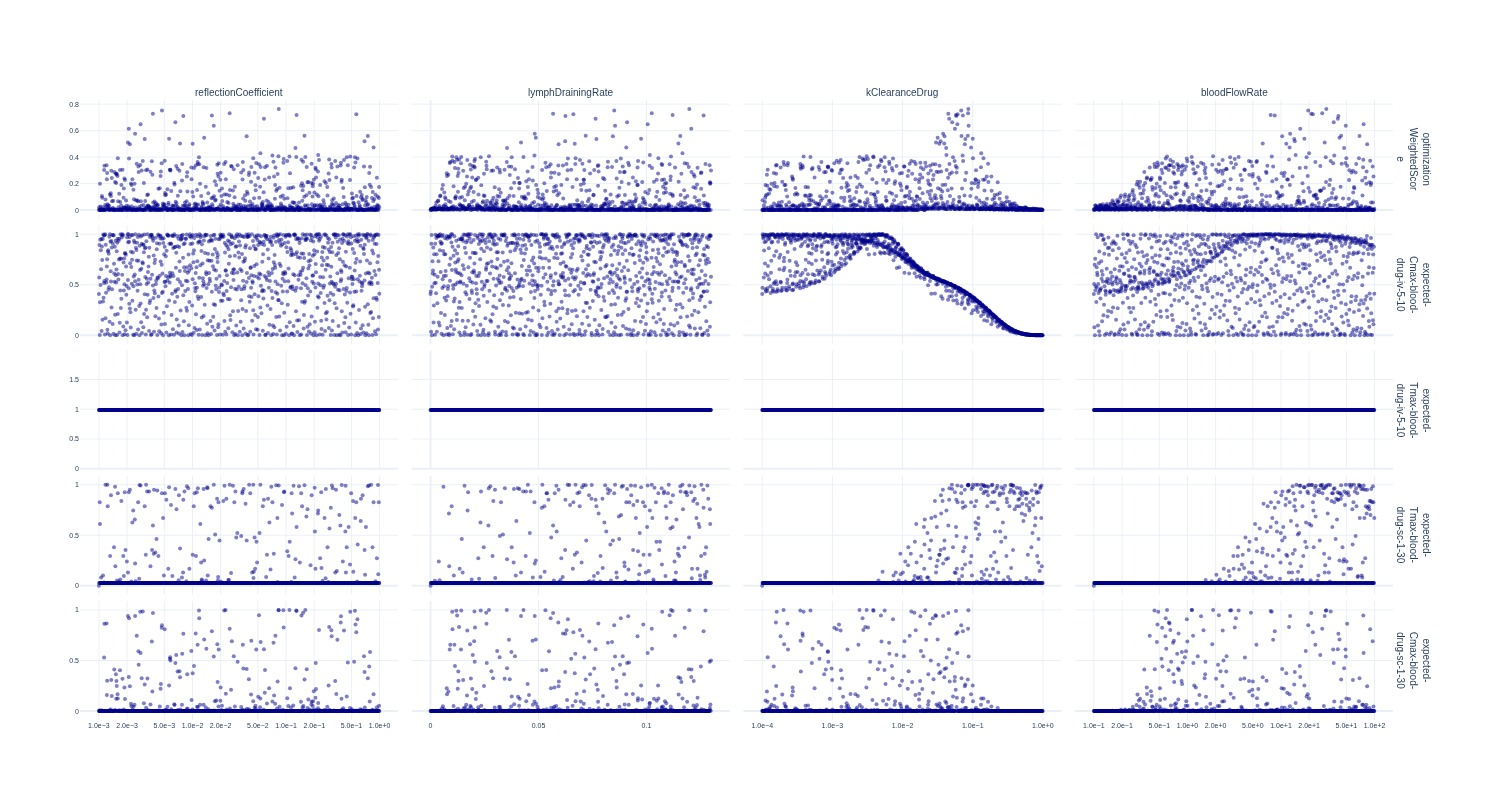

In [12]:
figureHeight = 800
figureWidth = 1500

scoreList = list(dfFull.score.unique())
scoreList.remove("optimizationWeightedScore")
scoreList = [
    "optimizationWeightedScore"
] + scoreList  # comment this line to plot only "optimizationWeightedScore"
nbScores = len(scoreList)

scoreListWrapped = ["<br>".join(textwrap.wrap(t, width=12)) for t in scoreList]

nbParams = len(parameters)
parametersWrapped = [
    "<br>".join(textwrap.wrap(parameter["id"], width=30)) for parameter in parameters
]

fig = make_subplots(
    len(scoreList),
    len(parameters),
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.01,
    vertical_spacing=0.01,
    column_titles=parametersWrapped,
    row_titles=scoreListWrapped,
)
for i in range(nbScores):
    for j in range(nbParams):
        scatter_df = dfFull.loc[
            (dfFull["parameterName"] == parameters[j]["id"])
            & (dfFull["score"] == scoreList[i])
        ]
        fig.add_trace(
            go.Scatter(
                x=scatter_df["parameterValue"],
                y=scatter_df["likelihoodTrans"],
                mode="markers",
                marker=dict(size=4, color="darkblue", opacity=0.5),
                hoverinfo="none",
            ),
            row=i + 1,
            col=j + 1,
        )

        if parameter_log_scaled(parameters[j]):
            fig.update_xaxes(type="log", row=i + 1,
                             col=j + 1, tickformat=".1e")
fig.update_annotations(font_size=10)
fig.update_layout(
    font=dict(size=7),
    showlegend=False,
    width=figureWidth,
    height=figureHeight,
    template="plotly_white",
)
fig.show(renderer="jpeg")

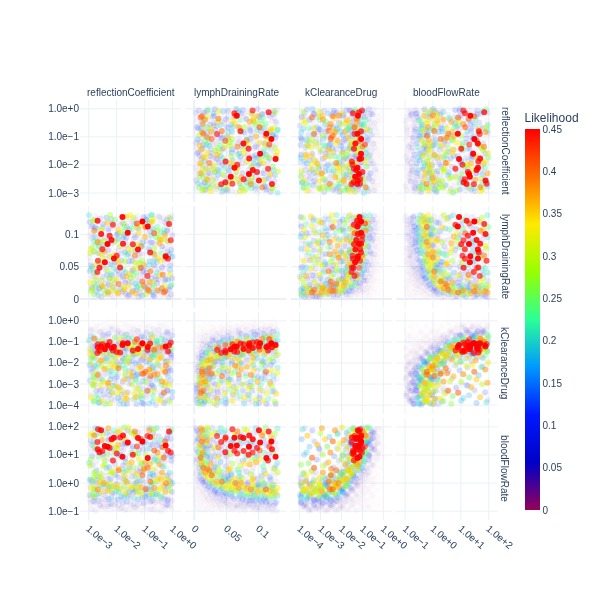

In [13]:
# Add here all params that should be displayed using a log scale
# By default, all params that had a custom range in log are selected
figureHeight = 600
figureWidth = 600

fig = make_subplots(
    len(parameters),
    len(parameters),
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.01,
    vertical_spacing=0.01,
    column_titles=parametersWrapped,
    row_titles=parametersWrapped,
)
for i in range(nbParams):  # iterating over rows
    for j in range(nbParams):  # iterating over columns
        if i == j:  # do not plot anything on the diagonal
            fig.add_trace(
                go.Scatter(x=[], y=[]),
                row=i + 1,
                col=j + 1,
            )
        else:
            df_j = dfFull.loc[
                (dfFull["parameterName"] == parameters[j]["id"])
                & (dfFull["score"] == "optimizationWeightedScore")
            ]
            df_j = df_j[["parameterValue", "likelihoodTrans", "patientId"]].rename(
                columns={"parameterValue": parameters[j]["id"]}
            )
            df_i = dfFull.loc[
                (dfFull["parameterName"] == parameters[i]["id"])
                & (dfFull["score"] == "optimizationWeightedScore")
            ]
            df_i = df_i[["parameterValue", "patientId"]].rename(
                columns={"parameterValue": parameters[i]["id"]}
            )

            scatter_df = df_j.merge(df_i, how="inner", on=["patientId"])
            scatter_df = scatter_df.sort_values(by="likelihoodTrans")
            fig.add_trace(
                go.Scatter(
                    # x axis is the column parameter
                    x=scatter_df[parameters[j]["id"]],
                    # y axis is the row parameter
                    y=scatter_df[parameters[i]["id"]],
                    mode="markers",
                    marker=dict(
                        size=6,
                        color=scatter_df["likelihoodTrans"],
                        opacity=(
                            scatter_df["likelihoodTrans"]
                            / scatter_df["likelihoodTrans"].max()
                        ),
                        coloraxis="coloraxis1",
                    ),
                    hoverinfo="none",
                ),
                row=i + 1,
                col=j + 1,
            )

        # Set the log scale for x and / or y axes
        if parameter_log_scaled(parameters[j]):
            fig.update_xaxes(type="log", row=i + 1,
                             col=j + 1, tickformat=".1e")
        if parameter_log_scaled(parameters[i]):
            fig.update_yaxes(type="log", row=i + 1,
                             col=j + 1, tickformat=".1e")
fig.update_annotations(font_size=10)
fig.update_xaxes(tickangle=40)
fig.update_coloraxes(
    colorbar_title="Likelihood",
    cmin=0,
    cmax=0.45,
    colorscale="Rainbow",
    colorbar_thickness=15,
)
fig.update_layout(
    font=dict(size=10),
    showlegend=False,
    width=figureWidth,
    height=figureHeight,
    template="plotly_white",
)
fig.show(renderer="jpeg")